# Machine Learning - CandNo 291144

## Preprocessing

### Handling Null Values and Missing Data

#### Importing Libraries

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score,mean_squared_error
from scipy.stats import pearsonr

data_path = "./ML_dataset/" 
output_path = "./Processed_dataset/"

if not os.path.exists(output_path):
    os.mkdir(output_path)

#### country_latitude_longitude null values

In [2]:
df_country_lat_long = pd.read_csv(data_path + "country_latitude_longitude_area_lookup.csv")

# Find missing rows which are the ones that have null values or zero radius
country_lat_long_missing_rows = df_country_lat_long[(df_country_lat_long.isnull().any(axis=1)) | (df_country_lat_long['centroid radius'] == 0)]

# Remove missing rows
df_country_lat_long_cleaned = df_country_lat_long.drop(country_lat_long_missing_rows.index)

print("Missing rows:")
country_lat_long_missing_rows.head(20)

Missing rows:


,centroid latitude,centroid longitude,country,area,centroid radius
28,-54.423199,3.413194,Bouvet Island,NaN,0.0
30,-6.343194,71.876519,British Indian Ocean Territory,NaN,0.0
76,-49.280366,69.348557,French Southern Territories,NaN,0.0
79,31.354676,34.308825,Gaza Strip,NaN,0.0
139,-12.827500,45.166244,Mayotte,NaN,0.0
227,NaN,NaN,U.S. Minor Outlying Islands,NaN,0.0
237,41.902916,12.453389,Vatican City,0,0.0


#### TWS_inst_data Month 2, 3 impute data

Missing rows in TWS_inst_data.csv before imputation:
TWS_inst_month_2    14946
TWS_inst_month_3    14946
dtype: int64
Missing rows after imputation:
TWS_inst_month_2    0
TWS_inst_month_3    0
dtype: int64


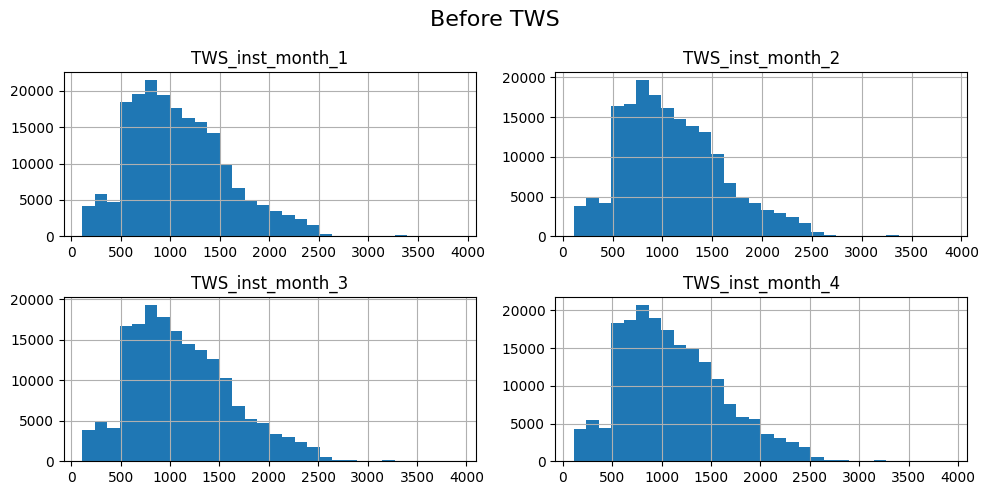

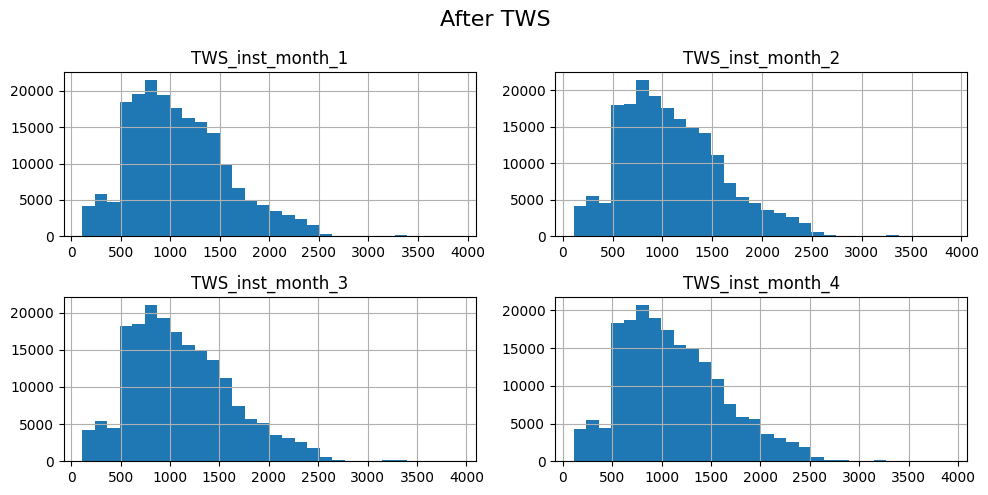

In [3]:
tws_df = pd.read_csv(data_path + "TWS_inst_data.csv")
tws_df_copy = tws_df.copy()

tws_cols_to_impute = ['TWS_inst_month_2', 'TWS_inst_month_3']
print("Missing rows in TWS_inst_data.csv before imputation:")
print(tws_df[tws_cols_to_impute].isnull().sum())

# Impute using row mean
tws_df['TWS_inst_month_2'] = tws_df.apply(
    lambda row: row['TWS_inst_month_2'] if not pd.isnull(row['TWS_inst_month_2']) else 
    (2 * row['TWS_inst_month_1'] + row['TWS_inst_month_4']) / 3, axis=1
)
tws_df['TWS_inst_month_3'] = tws_df.apply(
    lambda row: row['TWS_inst_month_3'] if not pd.isnull(row['TWS_inst_month_3']) else 
    (row['TWS_inst_month_1'] + 2 * row['TWS_inst_month_4']) / 3, axis=1
)

print("Missing rows after imputation:")
print(tws_df[tws_cols_to_impute].isnull().sum())
tws_df_copy[['TWS_inst_month_1','TWS_inst_month_2', 'TWS_inst_month_3','TWS_inst_month_4']].hist(figsize=(10, 5), bins=30)
plt.suptitle("Before TWS", fontsize=16)
plt.tight_layout()
plt.show()
tws_df[['TWS_inst_month_1','TWS_inst_month_2', 'TWS_inst_month_3','TWS_inst_month_4']].hist(figsize=(10, 5), bins=30)
plt.suptitle("After TWS", fontsize=16)
plt.tight_layout()
plt.show()

#### SoilMoi100_200cm_inst_data impute month 8

Missing rows in SoilMoi100_200cm_inst_data.csv before imputation:
14946
Missing rows after imputation:
0


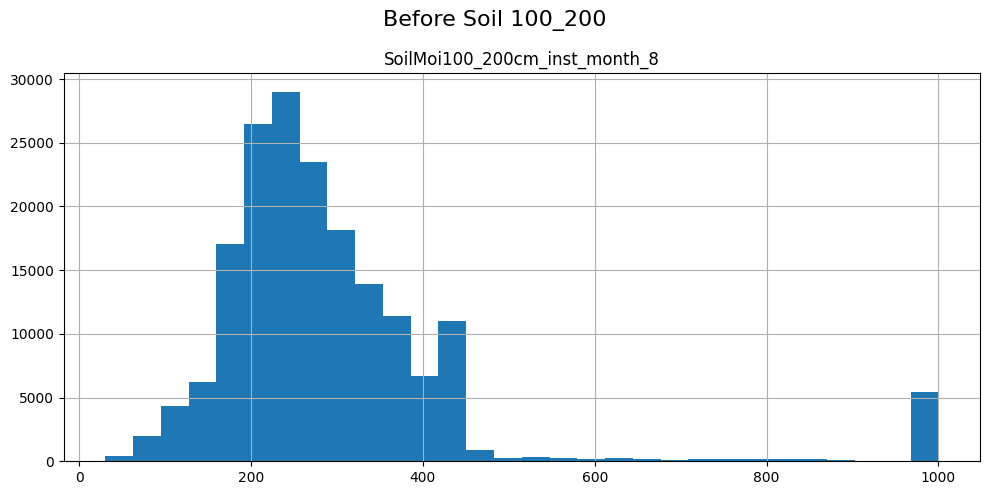

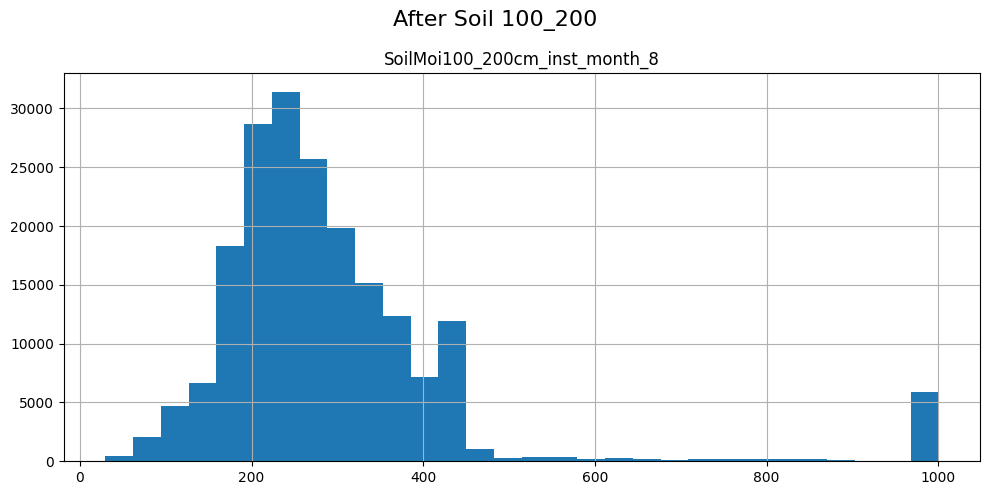

In [4]:
# SoilMoi100_200cm_inst_data.csv
soil_moi_100200_df = pd.read_csv(data_path + "SoilMoi100_200cm_inst_data.csv")
soil_moi_100200_df_copy = soil_moi_100200_df.copy()

# Impute SoilMoi100_200cm_inst_month_8 using the average of month 7 and month 9
soil_moi_100200_df['SoilMoi100_200cm_inst_month_8'] = soil_moi_100200_df.apply(
    lambda row: row['SoilMoi100_200cm_inst_month_8'] if not pd.isnull(row['SoilMoi100_200cm_inst_month_8']) else 
    (row['SoilMoi100_200cm_inst_month_7'] + row['SoilMoi100_200cm_inst_month_9']) / 2, axis=1
)

print("Missing rows in SoilMoi100_200cm_inst_data.csv before imputation:")
print(soil_moi_100200_df_copy['SoilMoi100_200cm_inst_month_8'].isnull().sum())
print("Missing rows after imputation:")
print(soil_moi_100200_df['SoilMoi100_200cm_inst_month_8'].isnull().sum())

soil_moi_100200_df_copy[['SoilMoi100_200cm_inst_month_8']].hist(figsize=(10, 5), bins=30)
plt.suptitle("Before Soil 100_200", fontsize=16)
plt.tight_layout()
plt.show()
soil_moi_100200_df[['SoilMoi100_200cm_inst_month_8']].hist(figsize=(10, 5), bins=30)
plt.suptitle("After Soil 100_200", fontsize=16)
plt.tight_layout()
plt.show()

### Merging columns to one number

#### Utility Functions

In [5]:
from calendar import monthrange

def calc_mean(df, prefix):
    monthly_cols = [f"{prefix}_{m}" for m in range(1, 13)]
    for m in range(1, 13):
        monthly_cols = [f"{prefix}_{m}" for m in range(1, 13)]
        yearly_mean_col = f"{prefix[:-6]}_yearly"
        df[yearly_mean_col] = df[monthly_cols].mean(axis=1)
        keep_cols = ["longitude", "latitude", "year", yearly_mean_col]
        return df[keep_cols]

def calc_mean_from_file(dataset_obj):
    df_arr = []
    for file_key, prefix in dataset_obj.items():
        df = pd.read_csv(data_path + file_key + ".csv")
        df_arr.append(calc_mean(df, prefix))
    return df_arr

def calc_temp(df, prefix):
    monthly_cols = [f"{prefix}_{m}" for m in range(1, 13)]
    k_to_c = 273.15
    df[f"{prefix[:-6]}_mean"] = df[monthly_cols].mean(axis=1) - k_to_c
    df[f"{prefix[:-6]}_min"] = df[monthly_cols].min(axis=1) - k_to_c
    df[f"{prefix[:-6]}_max"] = df[monthly_cols].max(axis=1) - k_to_c
    keep_cols = ["longitude", "latitude", "year", 
                 f"{prefix[:-6]}_mean", f"{prefix[:-6]}_min", f"{prefix[:-6]}_max"]
    return df[keep_cols]

def calc_temp_from_file(dataset_obj):
    df_arr = []
    for file_key, prefix in dataset_obj.items():
        df = pd.read_csv(data_path + file_key + ".csv")
        df_arr.append(calc_temp(df, prefix))
    return df_arr

def calc_prec_sum(df, prefix):
    monthly_cols = [f"{prefix}_{m}" for m in range(1, 13)]
    for m in range(1, 13):
        col = f"{prefix}_{m}"
        # converting Kilogram per squared metre per second
        # to millimetre per month
        # by multiplying by seconds in month
        # and dividing by 1000 to convert to mm
        # 3600 seconds in an hour x 24 hours in a day 
        # 3600 / 1000 = 3.6
        df[col] = df.apply(lambda r: r[col] * monthrange(int(r["year"]), m)[1] * 24 * 3.6, axis=1)
    
    yearly_total_col = f"{prefix[:-6]}_yearly"
    df[yearly_total_col] = df[monthly_cols].sum(axis=1)
    keep_cols = ["longitude", "latitude", "year", yearly_total_col]
    return df[keep_cols]

def calc_prec_sum_from_file(dataset_obj):
    df_arr = []
    for file_key, prefix in dataset_obj.items():
        df = pd.read_csv(data_path + file_key + ".csv")
        df_arr.append(calc_prec_sum(df, prefix))
    return df_arr


#### Calculating Soil moisture Mean values 

In [6]:
DATASET_SOIL = {
    "SoilMoi0_10cm_inst_data":    "SoilMoi0_10cm_inst_month",   
    "SoilMoi10_40cm_inst_data":   "SoilMoi10_40cm_inst_month",  
    "SoilMoi40_100cm_inst_data":  "SoilMoi40_100cm_inst_month", 
}
Soil_cleaned_df = calc_mean_from_file(DATASET_SOIL)
Soil_cleaned_df.append(calc_mean(soil_moi_100200_df, "SoilMoi100_200cm_inst_month"))

#### Calculating Soil Temp Mean value 

In [7]:
DATASET_TEMP = {
    "SoilTMP0_10cm_inst_data":    "SoilTMP0_10cm_inst_month",   
    "SoilTMP10_40cm_inst_data":   "SoilTMP10_40cm_inst_month",  
    "SoilTMP40_100cm_inst_data":  "SoilTMP40_100cm_inst_month", 
    "SoilTMP100_200cm_inst_data": "SoilTMP100_200cm_inst_month"
}
Temp_cleaned_df = calc_temp_from_file(DATASET_TEMP)

#### Calculating ESoil Mean value 

In [8]:
DATASET_ESOIL = {
    "ESoil_tavg_data":    "ESoil_tavg_month",   
}
Esoil_cleaned_df = calc_mean_from_file(DATASET_ESOIL)

#### Calculating TWS Mean value

In [9]:
TWS_cleaned_df = [calc_mean(tws_df, "TWS_inst_month")]

#### Calculating CanopInt Mean value 

In [10]:
DATASET_CANOP = {
    "CanopInt_inst_data":        "CanopInt_inst_month",        
}
Canop_cleaned_df = calc_mean_from_file(DATASET_CANOP)

#### Calculating TVEG Mean value

In [11]:
DATASET_TVEG = {
    "TVeg_tavg_data":            "TVeg_tavg_month",            
}
TVeg_cleaned_df = calc_mean_from_file(DATASET_TVEG)

#### Calculating Rain and Snow PRECIP Sum

In [12]:
DATASET_PRECIP = {
    "Snowf_tavg_data":           "Snowf_tavg_month",           
    "Rainf_tavg_data":           "Rainf_tavg_month",           
}
Precip_cleaned_df = calc_prec_sum_from_file(DATASET_PRECIP)

### Merging All Weather Points

#### Combine all weather dataframes

In [13]:
df_land_cover = pd.read_csv(data_path + "Land_cover_percent_data.csv")
df_land_cover.rename(columns={'Land_cover_percent_classh_4': 'Land_cover_percent_class_4'}, inplace=True)
w_dfs = [Soil_cleaned_df[1], Soil_cleaned_df[2], Soil_cleaned_df[3],
         Temp_cleaned_df[0], Temp_cleaned_df[1], Temp_cleaned_df[2],
         Temp_cleaned_df[3], Esoil_cleaned_df[0], TWS_cleaned_df[0],
         Canop_cleaned_df[0], TVeg_cleaned_df[0], Precip_cleaned_df[0],
         Precip_cleaned_df[1], df_land_cover]

merged_weather_df = Soil_cleaned_df[0]
for df in w_dfs:
    merged_weather_df = pd.merge(merged_weather_df, df,
                                 on=["longitude", "latitude", "year"], how="outer")

print("Shape of merged data:", merged_weather_df.shape)

Shape of merged data: (644280, 42)


#### Drop Null values from merged weather data

In [14]:
# some data is missing because of land_cover
merged_weather_df = merged_weather_df.dropna()
print("Shape of merged data:", merged_weather_df.shape)

Shape of merged data: (194298, 42)


### Merging All Country data with Weather points

In [15]:
def calc_haversine(lat1, lon1, lat2, lon2):
    Earth_radius = 6371
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = (np.sin(dlat / 2) ** 2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon / 2) ** 2)
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    distance = Earth_radius * c
    return distance

def choose_country(df, countries):
    df_copy = df.copy()
    for idx, row in tqdm(df_copy.iterrows(), total=len(df_copy), desc="Choosing countries"):
        # Finding all the distances from countries
        lat, lon = row["latitude"], row["longitude"]
        distances = countries.apply(
            lambda x: calc_haversine(lat, lon, x["centroid latitude"], x["centroid longitude"]),axis=1)
        
        countries_radius = countries["centroid radius"]
        in_common_countries = distances.where(distances <= countries_radius).dropna()
        closest_country_id = None
        
        # If no countries contain the point the closest one will be assigned
        if in_common_countries.empty:
            border_distance = distances - countries_radius
            closest_country_id = border_distance.idxmin()
        else:
            # If several countries contain the point, choose the one with the smallest distance
            border_distance = countries_radius - in_common_countries 
            # We are getting the max because we subtracted radius from distance and it tells us how far we are from the border
            closest_country_id = border_distance.idxmax()
        df_copy.at[idx, "Country"] = countries.loc[closest_country_id, "country"]
    return df_copy

merged_weather_country_df = choose_country(merged_weather_df, df_country_lat_long_cleaned)
merged_weather_country_df.drop(columns=['longitude', 'latitude'], inplace=True)
merged_weather_country_df.rename(columns={'year': 'Year'}, inplace=True)
cols = merged_weather_country_df.columns.tolist()
cols.insert(0, cols.pop(cols.index('Country')))
merged_weather_country_df = merged_weather_country_df[cols]

Choosing countries: 100%|██████████| 194298/194298 [06:26<00:00, 502.58it/s]


In [16]:
merged_weather_country_df.to_csv(output_path + "merged_weather_country.csv", index=False)

### Filtering Yield Data

In [17]:
yield_df = pd.read_csv(data_path + "Yield_and_Production_data.csv")
filtered_yield_df = yield_df[yield_df['Element'] == 'Yield']
filtered_yield_df = filtered_yield_df[['Country', 'Item', 'Year', 'Value']]
filtered_yield_df.reset_index(drop=True, inplace=True)

In [18]:
filtered_yield_df.head(10)

,Country,Item,Year,Value
0,Afghanistan,Apples,2010,7000.0
1,Afghanistan,Apples,2011,7000.0
2,Afghanistan,Apples,2012,7651.9
3,Afghanistan,Apples,2013,7600.5
4,Afghanistan,Apples,2014,7300.0
5,Afghanistan,Apples,2015,6882.4
6,Afghanistan,Apples,2016,7276.2
7,Afghanistan,Apples,2017,6348.7
8,Afghanistan,Apples,2018,7652.7
9,Afghanistan,Apples,2019,9083.2


In [19]:
filtered_yield_df.to_csv(output_path + "filtered_yield_data.csv", index=False)

### Merge all the points in a country to a single point with mean then merging it with yield data

In [20]:
merged_weather_compress = merged_weather_country_df.groupby(['Country', 'Year'], as_index=False).mean()
df_predict = merged_weather_compress[merged_weather_compress['Year'] == 2022].copy()
df_yield_2022 = filtered_yield_df[filtered_yield_df['Year'] == 2022][["Country", "Year", "Item", "Value"]]
df_predict = df_predict.merge(
    df_yield_2022,
    on=["Country", "Year"],
    how="inner"
)
df_predict.drop(columns=['Value'], inplace=True)
# Each year of weather data is related to next year's yield
yield_shifted = filtered_yield_df.copy()
yield_shifted['Year'] -= 1 

combined_df = merged_weather_compress.merge(
    yield_shifted[["Country", "Year", "Item", "Value"]],
    on=["Country", "Year"],
    how="inner"
)

combined_df.to_csv(output_path + 'combined_data.csv', index=False)
df_predict.to_csv(output_path + 'df_predict.csv', index=False)

In [21]:
# df_predict.head(5)
combined_df[combined_df['Year'] == 2010].head(5)


,Country,Year,SoilMoi0_10cm_inst_yearly,SoilMoi10_40cm_inst_yearly,SoilMoi40_100cm_inst_yearly,SoilMoi100_200cm_inst_yearly,SoilTMP0_10cm_inst_mean,SoilTMP0_10cm_inst_min,SoilTMP0_10cm_inst_max,SoilTMP10_40cm_inst_mean,...,Land_cover_percent_class_10,Land_cover_percent_class_11,Land_cover_percent_class_12,Land_cover_percent_class_13,Land_cover_percent_class_14,Land_cover_percent_class_15,Land_cover_percent_class_16,Land_cover_percent_class_17,Item,Value
0,Afghanistan,2010,16.919313,66.868168,133.859656,240.171177,16.11277,2.243422,28.32188,16.108834,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Apples,7000.0
1,Afghanistan,2010,16.919313,66.868168,133.859656,240.171177,16.11277,2.243422,28.32188,16.108834,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Apricots,8172.5
2,Afghanistan,2010,16.919313,66.868168,133.859656,240.171177,16.11277,2.243422,28.32188,16.108834,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Barley,1610.0
3,Afghanistan,2010,16.919313,66.868168,133.859656,240.171177,16.11277,2.243422,28.32188,16.108834,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Cantaloupes and other melons,10114.5
4,Afghanistan,2010,16.919313,66.868168,133.859656,240.171177,16.11277,2.243422,28.32188,16.108834,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Figs,4000.0


In [22]:
print("Unique Years combined:", combined_df['Year'].unique())
print("Unique Years predict:", df_predict['Year'].unique())

Unique Years combined: [2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021]
Unique Years predict: [2022]


In [23]:
print(combined_df.shape)
combined_df.head(5)

(62738, 43)


,Country,Year,SoilMoi0_10cm_inst_yearly,SoilMoi10_40cm_inst_yearly,SoilMoi40_100cm_inst_yearly,SoilMoi100_200cm_inst_yearly,SoilTMP0_10cm_inst_mean,SoilTMP0_10cm_inst_min,SoilTMP0_10cm_inst_max,SoilTMP10_40cm_inst_mean,...,Land_cover_percent_class_10,Land_cover_percent_class_11,Land_cover_percent_class_12,Land_cover_percent_class_13,Land_cover_percent_class_14,Land_cover_percent_class_15,Land_cover_percent_class_16,Land_cover_percent_class_17,Item,Value
0,Afghanistan,2010,16.919313,66.868168,133.859656,240.171177,16.11277,2.243422,28.32188,16.108834,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Apples,7000.0
1,Afghanistan,2010,16.919313,66.868168,133.859656,240.171177,16.11277,2.243422,28.32188,16.108834,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Apricots,8172.5
2,Afghanistan,2010,16.919313,66.868168,133.859656,240.171177,16.11277,2.243422,28.32188,16.108834,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Barley,1610.0
3,Afghanistan,2010,16.919313,66.868168,133.859656,240.171177,16.11277,2.243422,28.32188,16.108834,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Cantaloupes and other melons,10114.5
4,Afghanistan,2010,16.919313,66.868168,133.859656,240.171177,16.11277,2.243422,28.32188,16.108834,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Figs,4000.0


### Split the dataset

In [24]:
df_train = combined_df[(combined_df['Year'] >= 2010) & (combined_df['Year'] <= 2019)]
df_val = combined_df[(combined_df['Year'] >= 2020) & (combined_df['Year'] < 2022)]
df_train.to_csv(output_path + 'df_train.csv', index=False)
df_val.to_csv(output_path + 'df_val.csv', index=False)

In [25]:
print("Item unique:", len(combined_df["Item"].unique()))
print("Country unique:", len(combined_df["Country"].unique()))
print("train shape:", df_train.shape)
print("test shape: ", df_val.shape)
print("pred shape: ", df_predict.shape)
print("Unique Years train:", df_train['Year'].unique())
print("Unique Years test:", df_val['Year'].unique())

Item unique: 102
Country unique: 165
train shape: (52370, 43)
test shape:  (10368, 43)
pred shape:  (5190, 42)
Unique Years train: [2010 2011 2012 2013 2014 2015 2016 2017 2018 2019]
Unique Years test: [2020 2021]


### Utility Functions For Model

In [26]:
# if i just want to run from here
df_train = pd.read_csv(output_path + 'df_train.csv')
df_val = pd.read_csv(output_path + 'df_val.csv')
df_predict = pd.read_csv(output_path + 'df_predict.csv')

In [27]:
def compute_r2(model, data_loader):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for X_batch, y_batch, _ in data_loader:
            preds = model(X_batch).squeeze().cpu().numpy()
            targets = y_batch.squeeze().cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(targets)
    return r2_score(all_targets, all_preds)
def compute_pearsonr(model, data_loader):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for X_batch, y_batch, _ in data_loader:
            preds = model(X_batch).squeeze().cpu().numpy()
            targets = y_batch.squeeze().cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(targets)
    corr, _ = pearsonr(all_targets, all_preds)
    return corr

def compute_mse_rmse(model, data_loader):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for X_batch, y_batch, _ in data_loader:
            preds = model(X_batch).squeeze().cpu().numpy()
            targets = y_batch.squeeze().cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(targets)
    mse = mean_squared_error(all_targets, all_preds)
    rmse = np.sqrt(mse)
    return mse, rmse

class YieldDataset(Dataset):
    def __init__(self, X, y, weights):
        self.X = torch.tensor(X.toarray() if hasattr(X, 'toarray') else X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
        self.weights = torch.tensor(weights, dtype=torch.float32).unsqueeze(1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.weights[idx]
    
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.model(x)
    
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=130):
    train_losses, val_losses = [], []
    train_r2s, val_r2s = [], []
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch, w_batch in train_loader:
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = (criterion(preds, y_batch) * w_batch).mean()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch, w_batch in val_loader:
                preds = model(X_batch)
                loss = (criterion(preds, y_batch) * w_batch).mean()
                val_loss += loss.item()

        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))

        train_r2 = compute_r2(model, train_loader)
        val_r2 = compute_r2(model, val_loader)
        train_r2s.append(train_r2)
        val_r2s.append(val_r2)

        print(f"Epoch {epoch+1:2d}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, Train R^2: {compute_r2(model, train_loader):.4f}, Val R^2: {compute_r2(model, val_loader):.4f}")

    return train_losses, val_losses, train_r2s, val_r2s

### Combining and Adding Decay Weight

In [28]:
target_year = 2022
decay_lambda = 0.1
df_all = pd.concat([df_train, df_val], ignore_index=True)
df_all['year_diff'] = target_year - df_all['Year']
df_all['decay_weight'] = np.exp(-decay_lambda * df_all['year_diff'])
target_col = 'Value'
categorical_cols = ['Country', 'Item']
numeric_cols = df_all.select_dtypes(include=['float64', 'int64']).columns.difference(
    ['Year', 'Value', 'year_diff', 'decay_weight']
).tolist()
all_features = numeric_cols + categorical_cols + ['Year']

X_raw = df_all[all_features]
y_all = df_all[target_col].values
weights_all = df_all['decay_weight'].values


### Preprocessing Transform

In [29]:
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]), numeric_cols + ['Year']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

X_processed = preprocessor.fit_transform(X_raw)

#### Split for training

In [30]:
train_size = len(df_train)
X_train = X_processed[:train_size]
X_val = X_processed[train_size:]
y_train = y_all[:train_size]
y_val = y_all[train_size:]
w_train = weights_all[:train_size]
w_val = weights_all[train_size:]
train_dataset = YieldDataset(X_train, y_train, w_train)
val_dataset = YieldDataset(X_val, y_val, w_val)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
input_dim = X_processed.shape[1]
model = MLP(input_dim)
criterion = nn.MSELoss(reduction='none')
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### Training model

In [31]:
train_losses, val_losses, train_r2s, val_r2s = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=120)

Epoch  1, Train Loss: 148329397.6703, Val Loss: 278685784.1605, Train R^2: -0.3963, Val R^2: -0.3727
Epoch  2, Train Loss: 142697529.0427, Val Loss: 262720650.8025, Train R^2: -0.3415, Val R^2: -0.2943
Epoch  3, Train Loss: 135390273.0354, Val Loss: 243221458.7654, Train R^2: -0.2680, Val R^2: -0.1984
Epoch  4, Train Loss: 125767104.5372, Val Loss: 213283619.2346, Train R^2: -0.1600, Val R^2: -0.0514
Epoch  5, Train Loss: 115417963.5812, Val Loss: 198544891.0247, Train R^2: -0.0973, Val R^2: 0.0211
Epoch  6, Train Loss: 102985168.0244, Val Loss: 163336294.2654, Train R^2: 0.0588, Val R^2: 0.1942
Epoch  7, Train Loss: 90774069.4676, Val Loss: 124052422.6975, Train R^2: 0.2535, Val R^2: 0.3876
Epoch  8, Train Loss: 79194618.4420, Val Loss: 114442804.8025, Train R^2: 0.2706, Val R^2: 0.4349
Epoch  9, Train Loss: 67957168.6062, Val Loss: 76392218.0309, Train R^2: 0.4847, Val R^2: 0.6223
Epoch 10, Train Loss: 57911772.9063, Val Loss: 69173772.4352, Train R^2: 0.5553, Val R^2: 0.6580
Epoch 1

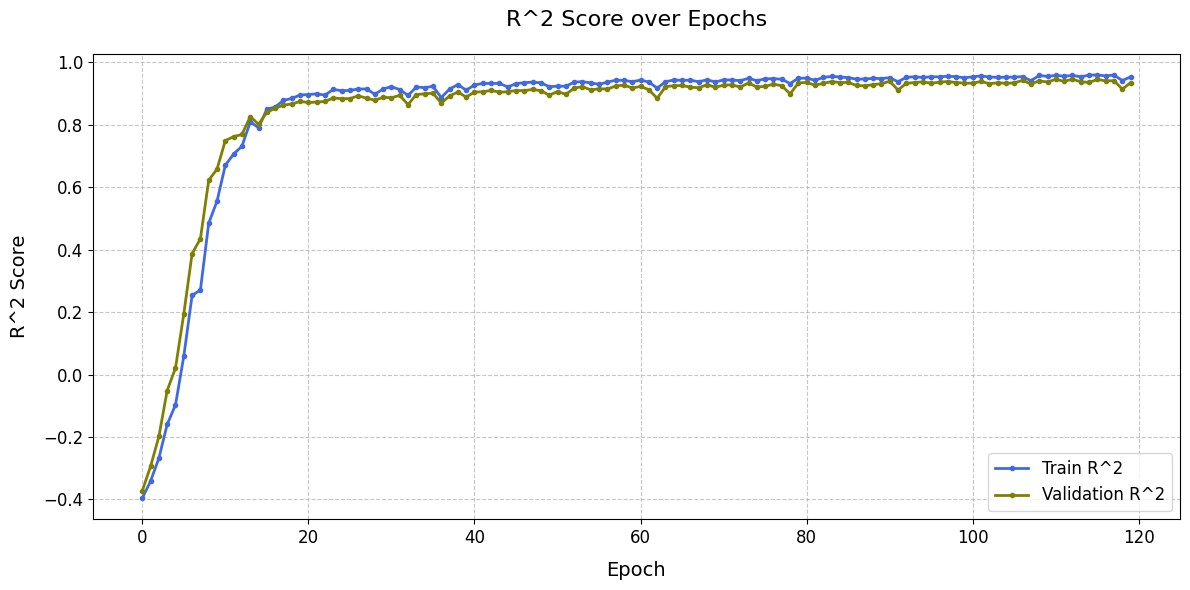

In [32]:
plt.figure(figsize=(12, 6))
plt.plot(train_r2s, label='Train R^2', color='royalblue', linewidth=2, marker='.', markersize=6)
plt.plot(val_r2s, label='Validation R^2', color='olive', linewidth=2, marker='.', markersize=6)
plt.xlabel('Epoch', fontsize=14, labelpad=10)
plt.ylabel('R^2 Score', fontsize=14, labelpad=10)
plt.title('R^2 Score over Epochs', fontsize=16, pad=20)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

Final Validation R^2: 0.9346
Final Validation Pearson Correlation: 0.9681
Final Validation MSE: 15417325.0000
Final Validation RMSE: 3926.4902
Final Train MSE: 9629040.0000
Final Train RMSE: 3103.0693


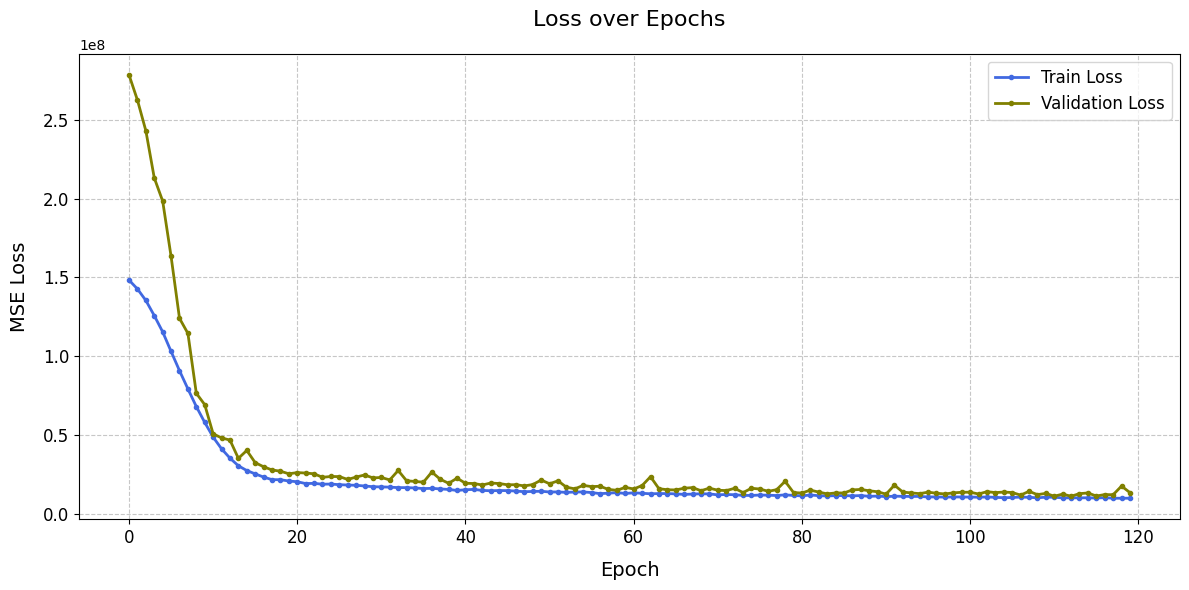

In [41]:
final_val_r2 = compute_r2(model, val_loader)
final_val_corr = compute_pearsonr(model, val_loader)
print(f"Final Validation R^2: {final_val_r2:.4f}")
print(f"Final Validation Pearson Correlation: {final_val_corr:.4f}")
val_mse, val_rmse = compute_mse_rmse(model, val_loader)
print(f"Final Validation MSE: {val_mse:.4f}")
print(f"Final Validation RMSE: {val_rmse:.4f}")

train_mse, train_rmse = compute_mse_rmse(model, train_loader)
print(f"Final Train MSE: {train_mse:.4f}")
print(f"Final Train RMSE: {train_rmse:.4f}")

plt.figure(figsize=(12, 6))
plt.plot(train_losses, label='Train Loss', color='royalblue', linewidth=2, marker='.', markersize=6)
plt.plot(val_losses, label='Validation Loss', color='olive', linewidth=2, marker='.', markersize=6)
plt.xlabel('Epoch', fontsize=14, labelpad=10)
plt.ylabel('MSE Loss', fontsize=14, labelpad=10)
plt.title('Loss over Epochs', fontsize=16, pad=20)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('./Processed_dataset/loss_plot.png')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


### Predicting 

In [ ]:
X_predict_raw = df_predict.copy()
X_predict_processed = preprocessor.transform(X_predict_raw)
X_predict_dense = X_predict_processed.toarray()

model.eval()
with torch.no_grad():
    X_predict_tensor = torch.tensor(X_predict_dense, dtype=torch.float32)
    preds = model(X_predict_tensor).squeeze().cpu().numpy()

df_predict['Predicted_Value'] = preds
print(df_predict[['Year', 'Country', 'Item', 'Predicted_Value']].sample(5))
df_predict.to_csv(output_path + 'predicted.csv', index=False)



      Year             Country                           Item  Predicted_Value
1130  2022            Colombia  Groundnuts, excluding shelled      3022.988037
1659  2022            Ethiopia                     Beans, dry       904.059326
4024  2022              Serbia                         Grapes      8669.155273
14    2022         Afghanistan           Other fruits, n.e.c.      8623.193359
1421  2022  Dominican Republic                        Bananas     35570.050781


In [ ]:
df_2021 = df_val[df_val["Year"] == 2021].copy()
true_yield_2021 = df_2021["Value"].values
X_2021_raw = df_2021[all_features]
X_2021_processed = preprocessor.transform(X_2021_raw)
X_2021_tensor = torch.tensor(X_2021_processed.toarray(), dtype=torch.float32)
model.eval()
with torch.no_grad():
    y_pred_2021 = model(X_2021_tensor).squeeze().cpu().numpy()
df_2021["Predicted_Value"] = y_pred_2021
df_2021["True_Value"] = true_yield_2021
output_cols = ["Country", "Item", "True_Value", "Predicted_Value"]
df_2021[output_cols].to_csv(output_path + "predicted_with_truth.csv", index=False)